## 1. Import Libraries & Dependencies

In [788]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [789]:
rng = np.random.default_rng(42)

## 2. Load the Dataset

In [790]:
data_train = pd.read_csv("mnist_train.csv")
data_test = pd.read_csv("mnist_test.csv")

## 3. Convert DataFrames to NumPy Arrays

In [791]:
data_train = data_train.to_numpy()
data_test = data_test.to_numpy()

In [792]:
data_train.shape

(60000, 785)

In [793]:
data_test.shape

(10000, 785)

## 5. Feature and Target Splitting ($X$ / $y$ Split)

In [794]:
X_train = data_train[:,1:]
y_train = data_train[:,0]
X_test = data_test[:,1:]
y_test = data_test[:,0]

## 6. Data Visualization & Sample Inspection

In [795]:
first_image = data_train[0][1:].reshape(28,28)
data_train[0][0]

np.int64(5)

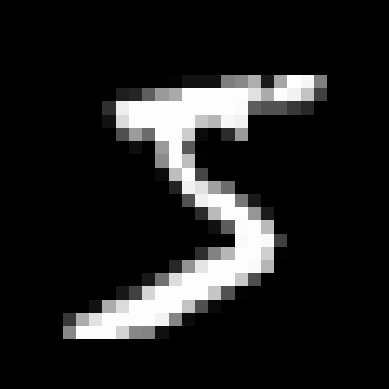

In [796]:
plt.imshow(first_image, cmap='gray')
plt.axis('off')
plt.show()

## resape

In [797]:
X_train = X_train.reshape(-1,1,28,28)
X_test = X_test.reshape(-1,1,28,28)

In [798]:
X_train.shape

(60000, 1, 28, 28)

## Zero-center

In [799]:
mean_image = np.mean(X_test,axis=0)
X_train = X_train - mean_image
X_test = X_test - mean_image

## ReLU

In [800]:
def relu(x):
    return np.maximum(0,x)

## Padding

In [801]:
def padding(x,pad = 1):

    num_row = x.shape[2]
    num_column = x.shape[3]

    new_column = num_column + 2*pad
    new_row = num_row + 2*pad

    zeros = np.zeros((x.shape[0],1,new_row,new_column))
    print(zeros.shape)
    for i in range(x.shape[0]):
        zeros[i,0,pad:pad+num_row,pad:pad + num_column] = x[i,0]

    return zeros

In [802]:
def padding_with_numpy(x,pad = 1):
    return np.pad(x,((0,0),(0,0),(pad,pad),(pad,pad)),mode='constant',constant_values=0)

In [803]:
matrix_test = np.arange(24000).reshape(60,1,20,20)

In [804]:
ft = np.array([[0,1,0],
                  [0,1,0],
                  [0,1,0]])


In [805]:
ft

array([[0, 1, 0],
       [0, 1, 0],
       [0, 1, 0]])

In [806]:
matrix_test.shape

(60, 1, 20, 20)

### vanilla convolution

In [807]:
def vanilla_conv(x,filters,stride =1):

    out_row = int(np.floor((x.shape[2]-filters.shape[0])/stride) + 1)
    out_col = int(np.floor((x.shape[3]-filters.shape[0])/stride) + 1)
    empty = np.zeros((x.shape[0],x.shape[1],out_row,out_col))
    for i in range(x.shape[0]):
        for j in range(out_row):
            for k in range(out_col):
                empty[i,0,j,k] = np.einsum('ij,ij->',x[i,0,j:j+filters.shape[0],k:k+filters.shape[0]],filters)

    return empty

 ### vanilla max Pooling

In [808]:
def vanilla_maxpool(max_pool_input,size_filter = 2 ,stride = 1):

    row_size = max_pool_input.shape[2]
    output_size = int((row_size - size_filter)//stride) +1
    output_maxpool = np.zeros((max_pool_input.shape[0],1,output_size,output_size))

    for i in range(max_pool_input.shape[0]):
        for j in range(output_size):
            for k in range(output_size):
                h_start = j * stride
                v_start = k * stride
                output_maxpool[i,0,j,k] = np.max(max_pool_input[i,0,h_start:h_start+size_filter,v_start:v_start+size_filter])
    return output_maxpool

## im2col

### convolution with im2col

In [809]:
def convolution(input_conv, filters, biases, stride=1):
    number_of_input = input_conv.shape[0]
    in_channels = input_conv.shape[1]
    number_of_row = input_conv.shape[2]

    num_filters = filters.shape[0]
    size_filter = filters.shape[2]

    output_size = int((number_of_row - size_filter) // stride + 1)
    output_conv = np.zeros((number_of_input, num_filters, output_size, output_size))

    for i in range(number_of_input):
        for f in range(num_filters):
            # 🟢 استخراج بایاس به صورت یک عدد اسکالر قبل از شروع حلقه‌های داخلی
            # این کار باعث افزایش سرعت هم می‌شود چون دیگر در هر تکرار نیاز به استخراج نیست
            bias_scalar = biases[f].item()

            for j in range(output_size):
                for k in range(output_size):
                    h_start = j * stride
                    v_start = k * stride

                    patch = input_conv[i, :, h_start:h_start+size_filter, v_start:v_start+size_filter]

                    # 🟢 حالا فقط از bias_scalar که یک عدد است استفاده می‌کنیم
                    output_conv[i, f, j, k] = np.sum(patch * filters[f]) + bias_scalar

    return output_conv

### conv of backward

In [810]:
def convolution_backward(dout, input_conv, filters, stride=1):
    """
    dout: گرادینت دریافتی از لایه بعدی با ابعاد (N, num_filters, out_H, out_W)
    input_conv: ورودی اصلی که در پاس رفت به این لایه داده شده بود با ابعاد (N, in_channels, H, W)
    filters: وزن‌های فیلتر با ابعاد (num_filters, in_channels, filter_size, filter_size)
    """
    number_of_input = input_conv.shape[0]   # N
    in_channels = input_conv.shape[1]       # C
    num_filters = filters.shape[0]          # F
    size_filter = filters.shape[2]          # FH (سایز فیلتر)

    out_H = dout.shape[2]
    out_W = dout.shape[3]

    # ۱. ایجاد آرایه‌های صفر برای ذخیره گرادینت‌ها
    d_input = np.zeros_like(input_conv)
    d_filters = np.zeros_like(filters)
    d_biases = np.zeros(num_filters)

    # ۲. محاسبه گرادینت‌ها با حلقه
    for i in range(number_of_input):
        for f in range(num_filters):

            # گرادینت بایاس برابر است با مجموع تمام مقادیر dout در آن فیلتر
            d_biases[f] += np.sum(dout[i, f])

            for j in range(out_H):
                for k in range(out_W):
                    h_start = j * stride
                    v_start = k * stride

                    # استخراج همان پچی که در پاس رفت استفاده شده بود
                    patch = input_conv[i, :, h_start:h_start+size_filter, v_start:v_start+size_filter]

                    # گرادینت نسبت به فیلتر fام (ضرب پچ در مقدار گرادینت متناظر)
                    d_filters[f] += patch * dout[i, f, j, k]

                    # گرادینت نسبت به ورودی (ضرب فیلتر در مقدار گرادینت متناظر و جمع انباشته)
                    d_input[i, :, h_start:h_start+size_filter, v_start:v_start+size_filter] += filters[f] * dout[i, f, j, k]

    return d_input, d_filters, d_biases

### max pooling

In [811]:
def max_pooling(input_maxpool, size_filter=2, stride=2):
    mask = np.zeros_like(input_maxpool)
    number_of_input = input_maxpool.shape[0]
    num_channels = input_maxpool.shape[1] # اضافه شدن بعد کانال‌ها
    number_of_row = input_maxpool.shape[2]

    output_size = int((number_of_row - size_filter) // stride + 1)
    output_maxpool = np.zeros((number_of_input, num_channels, output_size, output_size))

    for i in range(number_of_input):
        for c in range(num_channels): # حلقه روی تک‌تک کانال‌ها
            for j in range(output_size):
                for k in range(output_size):
                    h_start = j * stride
                    v_start = k * stride

                    patch = input_maxpool[i, c, h_start:h_start+size_filter, v_start:v_start+size_filter]
                    output_maxpool[i, c, j, k] = np.max(patch)

                    # پیدا کردن ایندکس ماکزیمم برای اعمال ماسک معکوس در بک‌پراپ
                    r, w_idx = np.unravel_index(np.argmax(patch), patch.shape)
                    mask[i, c, h_start + r, v_start + w_idx] = 1

    return output_maxpool, mask

### max pool backward

In [812]:
def max_pool_backward(dloss_in, mask, size_filter=2, stride=2):
    """
    dloss_in: گرادینت خطا از لایه بعدی با ابعاد (N, C, out_H, out_W)
    mask: ماتریس ماسک ساخته شده در پاس رفت با ابعاد (N, C, H, W)
    """
    number_of_input = dloss_in.shape[0]  # N
    num_channels = dloss_in.shape[1]     # C
    output_size = dloss_in.shape[2]      # out_H (یا همان out_W)

    # ۱. ماتریس گرادینت خروجی را با صفر مقداردهی اولیه می‌کنیم
    d_input = np.zeros_like(mask)

    # ۲. پخش کردن گرادینت‌ها با توجه به ماسک
    for i in range(number_of_input):
        for c in range(num_channels):  # اضافه شدن حلقه روی کانال‌ها
            for j in range(output_size):
                for k in range(output_size):

                    h_start = j * stride
                    v_start = k * stride

                    # استخراج پچ ماسک مربوط به این کانال و این موقعیت
                    mask_patch = mask[i, c, h_start:h_start+size_filter, v_start:v_start+size_filter]

                    # گرادینت آمده از لایه بعد برای این بخش (یک عدد اسکالر)
                    grad = dloss_in[i, c, j, k]

                    # ضرب ماسک (که فقط یک جا ۱ دارد) در گرادینت و قرار دادن در ماتریس نهایی
                    d_input[i, c, h_start:h_start+size_filter, v_start:v_start+size_filter] = mask_patch * grad

    return d_input

## avg pooling

In [813]:
def avg_pooling(input_avg, size_filter=2, stride=2):
    number_of_input = input_avg.shape[0]
    num_channels = input_avg.shape[1]
    number_of_row = input_avg.shape[2]

    output_size = int((number_of_row - size_filter) // stride + 1)
    output_avg_pooling = np.zeros((number_of_input, num_channels, output_size, output_size))

    for i in range(number_of_input):
        for c in range(num_channels):
            for j in range(output_size):
                for k in range(output_size):
                    h_start = j * stride
                    v_start = k * stride

                    patch = input_avg[i, c, h_start:h_start+size_filter, v_start:v_start+size_filter]
                    output_avg_pooling[i, c, j, k] = np.mean(patch)

    return output_avg_pooling

### avg_pool_backward

In [814]:
def avg_pool_backward(dloss_in, input_shape, size_filter=2, stride=2):
    """
    dloss_in: گرادینت خطا از لایه بعدی با ابعاد (N, C, out_H, out_W)
    input_shape: ابعاد ورودی لایه در پاس رفت به صورت (N, C, H, W)
    """
    number_of_input = dloss_in.shape[0]
    num_channels = dloss_in.shape[1]
    output_size = dloss_in.shape[2] # همان out_H

    # ایجاد ماتریس گرادینت خروجی با ابعاد ورودی اصلی
    d_input = np.zeros(input_shape)

    # تعداد کل المان‌های موجود در هر پچ (مثلاً برای فیلتر ۲×۲ میشه ۴)
    pool_area = size_filter ** 2

    for i in range(number_of_input):
        for c in range(num_channels): # اضافه شدن حلقه کانال
            for j in range(output_size):
                for k in range(output_size):

                    h_start = j * stride
                    v_start = k * stride

                    # گرادینت آمده از لایه بعد تقسیم بر تعداد اعضای پچ
                    grad_value = dloss_in[i, c, j, k] / pool_area

                    # توزیع و جمع انباشته گرادینت روی تمام المان‌های پچ مورد نظر
                    d_input[i, c, h_start:h_start+size_filter, v_start:v_start+size_filter] += grad_value

    return d_input

## activation

In [815]:
def relu(x):
    return np.maximum(0,x)

In [816]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

## initialization

In [817]:
def xavier_init(shape):

    """
    برای لایه دنس: shape = (input_dim, output_dim)
    برای لایه کانو: shape = (num_filters, in_channels, height, width)
    """
    if len(shape) == 2:
        fan_in = shape[0]
    elif len(shape) == 4:
        fan_in = shape[1] * shape[2] * shape[3]
    else:
        raise ValueError("xavier_init_error")

    std = np.sqrt(1 / fan_in)
    return rng.normal(0,std, size = shape)

تله‌ی مخفی نامپای (بحرانی): اگر شبکه عصبی تو در یک تکرار (Epoch) به قدری اشتباه پیش‌بینی کند که احتمال یک کلاس را دقیقاً 0.0 تشخیص دهد، دستور np.log(0) مقدار -inf (منفی بی‌نهایت) را تولید می‌کند! ضرب این مقدار در برچسب‌ها باعث می‌شود کل خروجی لغزش کند و به عدد NaN (مخفف Not a Number) تبدیل شود و کل شبکه عصبی‌ات نابود شود.

In [818]:
def he_init(shape):
    """
    برای لایه دنس: shape = (input_dim, output_dim)
    برای لایه کانو: shape = (num_filters, in_channels, height, width)
    """
    if len(shape) == 2:
        fan_in = shape[0]
    elif len(shape) == 4:
        fan_in = shape[1] * shape[2] * shape[3]
    else:
        raise ValueError("he_init_error")

    std = np.sqrt(2 / fan_in)
    return rng.normal(0,std,size=shape)


## Cross entropy loss

In [819]:
def ce_loss(labels,predictions):
    predictions = np.clip(predictions, 1e-15, 1 - 1e-15)
    batch_size = labels.shape[0]
    return - np.sum(labels * np.log(predictions)) / batch_size

## Optimizer

In [820]:
def momentum(v_in,w,dw,lr,beta_1=0.9):
    v_t = beta_1 * v_in + (1 - beta_1) * dw
    w = w - lr * v_t
    return w , v_t

In [821]:
def rmsprop(s_in,w,dw,lr,beta_2=0.99 , epsilon = 1e-8):
    s = beta_2 * s_in + (1-beta_2) * np.power(dw,2)
    w = w - (lr /(np.sqrt(s) + epsilon) * dw)
    return w , s

In [822]:
def adam(v_in,s_in,w,dw,lr,t,beta_1=0.9,beta_2=0.99 , epsilon = 1e-8):
    v = beta_1 * v_in + (1 - beta_1) * dw
    s = beta_2 * s_in + (1-beta_2) * np.power(dw,2)
    v_hat = v/(1-beta_1 ** t)
    s_hat = s/(1-beta_2 ** t)
    w = w - lr / (np.sqrt(s_hat) + epsilon) * v_hat

    return w , s ,v

## class Neural Networks

In [823]:
class neural_networks():
    def __init__(self,input_dim,output_dim,layer_sizes,conv_list,mod_opt = "momentum",activation = sigmoid,initialize_weights = True):
        self.weights = []         # وزن‌های لایه‌های fc
        self.biases = []          # بایاس‌های لایه fc
        self.biases_conv = []     # بایاس‌های لایه‌های cnn
        self.filter_list = []     # فیلترها (کرنل‌ها) لایه‌های cnn

        self.fc_z_catche = []
        self.fc_a_catche = []
        self.conv_z_catche = []
        self.conv_a_catche = []
        self.mask_maxpool = []

        # لیست‌های نگهداری سرعت مومنتوم و میانگین متحرک rmsprop
        self.v_w_conv, self.v_b_conv = [], []
        self.s_w_conv, self.s_b_conv = [], []
        self.v_w_fc, self.v_b_fc = [], []
        self.s_w_fc, self.s_b_fc = [], []

        self.dloss_w_conv = []
        self.dloss_b_conv = []
        self.dloss_w_fc = []
        self.dloss_b_fc = []

        self.is_first_forward = True
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layer_sizes = layer_sizes
        self.conv_list = conv_list
        self.mod_opt = mod_opt
        self.activation = activation

        # فراخوانی تابع مقداردهی اولیه (نام متد تغییر کرد تا تداخل ایجاد نشود)
        if initialize_weights:
            self.initialize_weights()

    def initialize_weights(self):
        # گرفتن نام تابع فعال‌سازی برای شرط‌ها
        act_name = self.activation if isinstance(self.activation, str) else self.activation.__name__
        # ۱. مقداردهی اولیه لایه‌های کانولوشن (CNN)
        # انتقال به متد forward به دلیل نیاز به تعداد کانال ورودی (current_input.shape[1]) به صورت داینامیک

        # ۲. مقداردهی اولیه لایه‌های تماماً متصل (FC / Dense)
        current_layer = self.input_dim
        for i in range(len(self.layer_sizes)):
            fc_shape = (current_layer, self.layer_sizes[i])

            if act_name == "sigmoid":
                self.weights.append(xavier_init(fc_shape))
            elif act_name == "relu":
                self.weights.append(he_init(fc_shape))
            else:
                self.weights.append(rng.normal(0, 1, size=fc_shape))

            # اصلاح بعد بایاس برای جلوگیری از خطای برودکستینگ
            self.biases.append(np.zeros(self.layer_sizes[i]))
            current_layer = self.layer_sizes[i]


    def forward(self,x):
            print("\n========== FORWARD ==========")
            print("input =", x.shape)
            print("is_first_forward =", self.is_first_forward)
            print("len(filter_list) =", len(self.filter_list))


            self.fc_z_catche = []
            self.fc_a_catche = []
            self.conv_z_catche = []
            self.conv_a_catche = []
            self.mask_maxpool = []
            number_of_conv = -1 # شماره لایه های کانولوشن هست که می خواهیم داشته باشیم که موقع اعمال کانولوشن به مشکل نخوریم
            current_input = x

            act_name = self.activation if isinstance(self.activation, str) else self.activation.__name__
            if act_name == "sigmoid":# تعیین نوع اکتیوشن برای اعمال و مقدار دهی های اولی
                activation = sigmoid
            elif act_name == "relu": # اصلاح شد: استفاده از act_name به جای self.activation برای جلوگیری از خطای شرط پایتون
                activation = relu

            for i in range(len(self.conv_list)): # تعیین نوع ورودی لیست کانولوشن
                if self.conv_list[i][0] == "maxpool" :
                    current_input,mask = max_pooling(current_input
                                                ,self.conv_list[i][1]
                                                ,self.conv_list[i][2])

                    self.mask_maxpool.append(mask)
                    self.conv_a_catche.append(current_input)

                elif self.conv_list[i][0] == "avgpool" :
                    current_input = avg_pooling(current_input,
                                                self.conv_list[i][1],
                                                self.conv_list[i][2])

                    self.conv_a_catche.append(current_input)

                elif self.conv_list[i][0] == "conv" :

                    number_of_conv +=1

                    # مقداردهی فیلترها بر اساس تعداد کانال تصویر ورودی به صورت داینامیک
                    if self.is_first_forward:

                        if act_name == "sigmoid": # اینا فیلتر ها را ایجاد کردم برای کانو
                            self.filter_list.append(xavier_init((self.conv_list[i][1],
                                                                 current_input.shape[1],self.conv_list[i][2],
                                                                 self.conv_list[i][2])))

                            self.biases_conv.append(np.zeros((1, self.conv_list[i][1], 1, 1)))

                        elif act_name == "relu":
                            self.filter_list.append(he_init((self.conv_list[i][1],
                                                             current_input.shape[1],
                                                             self.conv_list[i][2],
                                                             self.conv_list[i][2])))

                            self.biases_conv.append(np.zeros((1, self.conv_list[i][1], 1, 1)))
                        else:
                            self.filter_list.append(rng.normal(0, 1, size=(self.conv_list[i][1], current_input.shape[1], self.conv_list[i][2], self.conv_list[i][2])))
                            self.biases_conv.append(np.zeros((1, self.conv_list[i][1], 1, 1)))

                    print("conv layer =", number_of_conv)
                    print("filter shape =", self.filter_list[number_of_conv].shape)
                    print("input shape =", current_input.shape)

                    # 🟢 اصلاح مهم: بایاس (و احتمالاً استراید) به داخل پرانتز تابع منتقل شد
                    # نکته: اگر تابع کانولوشن شما استراید (stride) هم می‌گیرد، آن را به شکل زیر اضافه کنید:
                    # z = convolution(current_input, self.filter_list[number_of_conv], self.biases_conv[number_of_conv], self.conv_list[i][3])
                    z = convolution(current_input, self.filter_list[number_of_conv], self.biases_conv[number_of_conv])

                    print("CONV OUTPUT SHAPE =", z.shape)
                    print("FILTER SHAPE =", self.filter_list[number_of_conv].shape)

                    self.conv_z_catche.append(z)
                    a = activation(z)
                    self.conv_a_catche.append(a)
                    current_input = a
                else:
                    raise ValueError("layer Error")


            if self.is_first_forward:
                for i in range(len(self.filter_list)):
                    self.v_w_conv.append(np.zeros_like(self.filter_list[i])) #مومنتوم : برای سرعت فیلترهای کانولوشن
                    self.v_b_conv.append(np.zeros_like(self.biases_conv[i])) #مومنتوم : برای سرعت بایاس‌های کانولوشن

                    self.s_w_conv.append(np.zeros_like(self.filter_list[i])) #ارمس پراپ : برای سرعت فیلترهای کانولوشن
                    self.s_b_conv.append(np.zeros_like(self.biases_conv[i])) #ارمس پراپ : برای سرعت بایاس‌های کانولوشن

            print("BEFORE FLATTEN:", current_input.shape)
            current_input = current_input.reshape(current_input.shape[0], -1) # رابط لایه کانولوشن به لایه دنس
            print("AFTER FLATTEN:", current_input.shape)

            for i in range(len(self.layer_sizes)-1):

                z = current_input @ self.weights[i] + self.biases[i].T
                self.fc_z_catche.append(z)
                a = activation(z)
                self.fc_a_catche.append(a)
                current_input = a

            print("FC INPUT SHAPE:", current_input.shape)
            z = current_input @ self.weights[-1] + self.biases[-1].T
            a = activation(z)

            self.fc_z_catche.append(z)
            self.fc_a_catche.append(a)

            if self.is_first_forward:
                for i in range(len(self.weights)):
                    self.v_w_fc.append(np.zeros_like(self.weights[i])) #مومنتوم : برای سرعت وزن‌های تمام‌متصل
                    self.v_b_fc.append(np.zeros_like((self.biases[i]))) #مومنتوم : برای سرعت بایاس‌های تمام‌متصل

                    self.s_w_fc.append(np.zeros_like(self.weights[i])) #ارمس پراپ : برای سرعت وزن‌های تمام‌متصل
                    self.s_b_fc.append(np.zeros_like((self.biases[i]))) #ارمس پراپ : برای سرعت بایاس‌های تمام‌متصل

            # 🟢 اصلاح مهم: خاموش کردن فلگ مقداردهی اولیه برای جلوگیری از ساخته شدن مجدد وزن‌ها در بچ‌های بعدی
            self.is_first_forward = False

            # 🟢 اصلاح مهم: متد فوروارد باید خروجی لایه آخر را برگرداند تا مقدار خطا قابل محاسبه باشد
            return a

    def backward(self, X, y_target):
        print("\n========== BACKWARD ==========")
        print("y =", y_target.shape)
        print("fc cache =", self.fc_a_catche[-1].shape)

        num_fc = len(self.weights)
        dloss_a_fc = [0] * num_fc
        dloss_z_fc = [0] * num_fc
        self.dloss_w_fc = [np.zeros_like(w) for w in self.weights]
        self.dloss_b_fc = [np.zeros_like(b) for b in self.biases]

        # 🟢 ترفند اول: محاسبه مستقیم خطای لایه آخر (بدون نیاز به Z کچ که باعث ارور می‌شد)
        dloss_z_fc[-1] = self.fc_a_catche[-1] - y_target

        # بک‌پراپ برای بخش Fully Connected
        for i in reversed(range(num_fc)):

            if i < num_fc - 1:
                # 🟢 ترفند دوم: استفاده از A به جای Z برای محاسبه مشتق ReLU
                dloss_z_fc[i] = dloss_a_fc[i] * (self.fc_a_catche[i] > 0).astype(int)

            self.dloss_b_fc[i] = np.sum(dloss_z_fc[i], axis=0, keepdims=True).T

            if i >= 1:
                self.dloss_w_fc[i] = self.fc_a_catche[i-1].T @ dloss_z_fc[i]
                dloss_a_fc[i-1] = dloss_z_fc[i] @ self.weights[i].T
            else:
                flattened_conv = self.conv_a_catche[-1].reshape(self.conv_a_catche[-1].shape[0], -1)
                self.dloss_w_fc[i] = flattened_conv.T @ dloss_z_fc[i]
                dloss_flat_conv = dloss_z_fc[i] @ self.weights[i].T

        # بررسی وجود conv_list و جلوگیری از ارور لیست خالی
        num_conv = len(self.conv_list) if (hasattr(self, 'conv_list') and len(self.conv_list) > 0) else len(self.filter_list)

        dloss_a_conv = [0] * num_conv
        dloss_z_conv = [0] * num_conv
        self.dloss_w_conv = [np.zeros_like(f) for f in self.filter_list]
        self.dloss_b_conv = [np.zeros_like(b) for b in self.biases_conv]

        # انتقال خطای فلت شده به ابعاد کانولوشن
        dloss_a_conv[-1] = dloss_flat_conv.reshape(self.conv_a_catche[-1].shape)

        conv_idx = len(self.filter_list) - 1

        # بک‌پراپ برای بخش Convolution
        for l in reversed(range(num_conv)):

            # 🟢 استفاده از A برای مشتق ReLU در بخش کانو
            dloss_z_conv[l] = dloss_a_conv[l] * (self.conv_a_catche[l] > 0).astype(int)
            input_to_this_layer = X if l == 0 else self.conv_a_catche[l-1]

            # گرادیان بایاس
            self.dloss_b_conv[conv_idx] = np.sum(dloss_z_conv[l], axis=(0, 2, 3), keepdims=True)

            # محاسبه دقیق گرادیان وزن‌های کانو
            grad_w = np.zeros_like(self.filter_list[conv_idx])
            N, F, H_out, W_out = dloss_z_conv[l].shape
            _, C, FH, FW = self.filter_list[conv_idx].shape
            stride = 1

            for n in range(N):
                for f in range(F):
                    for h in range(H_out):
                        for w in range(W_out):
                            h_start = h * stride
                            v_start = w * stride
                            patch = input_to_this_layer[n, :, h_start:h_start+FH, v_start:v_start+FW]
                            grad_w[f] += patch * dloss_z_conv[l][n, f, h, w]

            self.dloss_w_conv[conv_idx] = grad_w
            conv_idx -= 1

    def update(self,t,lr=0.001,beta1=0.9,beta2=0.999,epsilon = 1e-8):

            print("\n========== UPDATE ==========")
            if self.mod_opt == "momentum" :
                for l in reversed(range(len(self.filter_list))):

                    print("filter =", self.filter_list[l].shape)
                    print("grad =", self.dloss_w_conv[l].shape)
                    print("velocity =", self.v_w_conv[l].shape)
                    self.filter_list[l], self.v_w_conv[l] = momentum(self.v_w_conv[l], self.filter_list[l], self.dloss_w_conv[l], lr, beta1)
                    self.biases_conv[l], self.v_b_conv[l] = momentum(self.v_b_conv[l], self.biases_conv[l], self.dloss_b_conv[l], lr, beta1)

                for l in reversed(range(len(self.weights))):
                    # 🟢 اصلاح: تغییر شکل گرادیان بایاس برای جلوگیری از ایجاد ماتریس مربعی (Broadcasting Error)
                    self.dloss_b_fc[l] = self.dloss_b_fc[l].reshape(self.biases[l].shape)

                    self.weights[l], self.v_w_fc[l] = momentum(self.v_w_fc[l], self.weights[l], self.dloss_w_fc[l], lr, beta1)
                    self.biases[l], self.v_b_fc[l] = momentum(self.v_b_fc[l], self.biases[l], self.dloss_b_fc[l], lr, beta1)


            elif self.mod_opt == "rmsprop" :
                for l in reversed(range(len(self.filter_list))):
                    self.filter_list[l], self.s_w_conv[l] = rmsprop(self.s_w_conv[l],self.filter_list[l],self.dloss_w_conv[l],lr,beta2)
                    self.biases_conv[l], self.s_b_conv[l] = rmsprop(self.s_b_conv[l],self.biases_conv[l],self.dloss_b_conv[l],lr,beta2)

                for l in reversed(range(len(self.weights))):
                    # 🟢 اصلاح: هم‌شکل کردن گرادیان بایاس
                    self.dloss_b_fc[l] = self.dloss_b_fc[l].reshape(self.biases[l].shape)

                    # اصلاح متغیرهای dLoss_dw و dLoss_db
                    self.weights[l]  , self.s_w_fc[l] = rmsprop(self.s_w_fc[l],self.weights[l],self.dloss_w_fc[l],lr,beta2)
                    self.biases[l], self.s_b_fc[l]= rmsprop(self.s_b_fc[l], self.biases[l], self.dloss_b_fc[l], lr, beta2)

            elif self.mod_opt == "adam" :
                for l in reversed(range(len(self.filter_list))):
                    self.filter_list[l], self.s_w_conv[l], self.v_w_conv[l]  = adam(self.v_w_conv[l],self.s_w_conv[l],self.filter_list[l],self.dloss_w_conv[l],lr,t,beta1,beta2)
                    self.biases_conv[l], self.s_b_conv[l] , self.v_b_conv[l]= adam(self.v_b_conv[l] ,self.s_b_conv[l],self.biases_conv[l],self.dloss_b_conv[l],lr,t,beta1,beta2)

                for l in reversed(range(len(self.weights))):
                    # 🟢 اصلاح: هم‌شکل کردن گرادیان بایاس
                    self.dloss_b_fc[l] = self.dloss_b_fc[l].reshape(self.biases[l].shape)

                    # اصلاح متغیرهای dLoss_dw و dLoss_db
                    self.weights[l]  , self.s_w_fc[l], self.v_w_fc[l]  = adam(self.v_w_fc[l],self.s_w_fc[l],self.weights[l],self.dloss_w_fc[l],lr,t,beta1,beta2)
                    self.biases[l], self.s_b_fc[l], self.v_b_fc[l]= adam(self.v_b_fc[l],self.s_b_fc[l], self.biases[l], self.dloss_b_fc[l],lr,t,beta1,beta2)

            else:
                for l in reversed(range(len(self.filter_list))):
                    self.filter_list[l] -= lr * self.dloss_w_conv[l]
                    self.biases_conv[l] -= lr * self.dloss_b_conv[l]

                for l in reversed(range(len(self.weights))):
                    # 🟢 اصلاح: هم‌شکل کردن گرادیان بایاس
                    self.dloss_b_fc[l] = self.dloss_b_fc[l].reshape(self.biases[l].shape)

                    # اصلاح متغیرهای dLoss_dw و dLoss_db
                    self.weights[l] -= lr * self.dloss_w_fc[l]
                    self.biases[l] -= lr * self.dloss_b_fc[l]

            # 🟢 اصلاح: بررسی امن برای چاپ ابعاد (چون متغیر l متعلق به حلقه قبلی است)
            if len(self.filter_list) > 0:
                print("after update =", self.filter_list[0].shape)

    def train(self, training_data, testing_data, epochs, batch_size, lr=0.001, beta1=0.9, beta2=0.99, epsilon=1e-8):
            self.training_data = training_data
            self.testing_data = testing_data

            # 🟢 اصلاح: کلمه model به self تغییر کرد تا خطای NameError رخ ندهد
            print("filters before train =", len(self.filter_list))

            size_x_train = self.training_data[0].shape[0]
            batch_index_size = int(np.ceil(size_x_train / batch_size))
            test_loss_list = []
            train_loss_list = []
            t = 0

            for epoch in range(epochs):
                # shuffle
                shuffle_index = rng.permutation(size_x_train)
                x_train_shuffled = self.training_data[0][shuffle_index]
                y_train_shuffled = self.training_data[1][shuffle_index]

                epoch_loss = 0

                for batch_index in range(batch_index_size):
                    t += 1
                    index_start = batch_index * batch_size
                    index_end = min(batch_index * batch_size + batch_size, size_x_train)

                    # داده‌های ورودی و برچسب فعلی
                    x_batch = x_train_shuffled[index_start:index_end]
                    y_batch = y_train_shuffled[index_start:index_end]

                    # رفت
                    print("filters during train =", len(self.filter_list))
                    out = self.forward(x_batch)

                    # برگشت (با بررسی ابعاد)
                    try:
                        self.backward(x_batch, y_batch)
                    except Exception as e:
                        print(f" خطا در Backward! ابعاد y_batch: {y_batch.shape}, ابعاد کچ لایه آخر: {self.fc_a_catche[-1].shape}")
                        raise e

                    # آپدیت
                    self.update(t, lr, beta1, beta2, epsilon)

                    # محاسبه خطا (با بررسی ابعاد)
                    try:
                        batch_loss = ce_loss(out, y_batch)
                    except Exception as e:
                        print(f"❌ خطا در Loss! ابعاد out: {out.shape}, ابعاد y_batch: {y_batch.shape}")
                        raise e

                    epoch_loss += batch_loss

                epoch_loss = epoch_loss / batch_index_size

                x_test_i, y_test_i = self.testing_data[0], self.testing_data[1]
                test_out = self.forward(x_test_i)
                test_loss = ce_loss(test_out, y_test_i)

                test_loss_list.append(test_loss)
                train_loss_list.append(epoch_loss)

                if epoch % 10 == 0:
                    # 🟢 اصلاح: عبارت MSE در پرینت به Loss تغییر کرد چون شما دارید از ce_loss (Cross Entropy) استفاده می‌کنید
                    print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {epoch_loss:.6f} | Test Loss: {test_loss:.6f}")

            plt.figure(figsize=(10,5))
            plt.plot(train_loss_list, label="Train Loss", color="blue")
            plt.plot(test_loss_list, label="Test Loss", color="red")
            plt.title('Training and Testing Loss Over Epochs', fontsize=14)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('Loss', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend(fontsize=12)
            plt.show()

در حال ساخت مدل...

=== شروع تست گام به گام ===

========== FORWARD ==========
input = (2, 1, 28, 28)
is_first_forward = True
len(filter_list) = 0
conv layer = 0
filter shape = (1, 1, 5, 5)
input shape = (2, 1, 28, 28)
CONV OUTPUT SHAPE = (2, 1, 24, 24)
FILTER SHAPE = (1, 1, 5, 5)
BEFORE FLATTEN: (2, 1, 24, 24)
AFTER FLATTEN: (2, 576)
FC INPUT SHAPE: (2, 128)
after forward: (1, 1, 5, 5)
✅ تست Forward با موفقیت انجام شد! ابعاد خروجی مدل: (2, 10)

========== BACKWARD ==========
y = (2, 10)
fc cache = (2, 10)
after backward: (1, 1, 5, 5)
✅ تست Backward با موفقیت انجام شد! گرادیان‌ها محاسبه شدند.

========== UPDATE ==========
filter = (1, 1, 5, 5)
grad = (1, 1, 5, 5)
velocity = (1, 1, 5, 5)
after update = (1, 1, 5, 5)
✅ تست Update با موفقیت انجام شد! وزن‌ها به‌روزرسانی شدند.

=== شروع تست متد جامع Train ===
filters before train = 1
filters during train = 1

========== FORWARD ==========
input = (2, 1, 28, 28)
is_first_forward = False
len(filter_list) = 1
conv layer = 0
filter shape = (1, 1

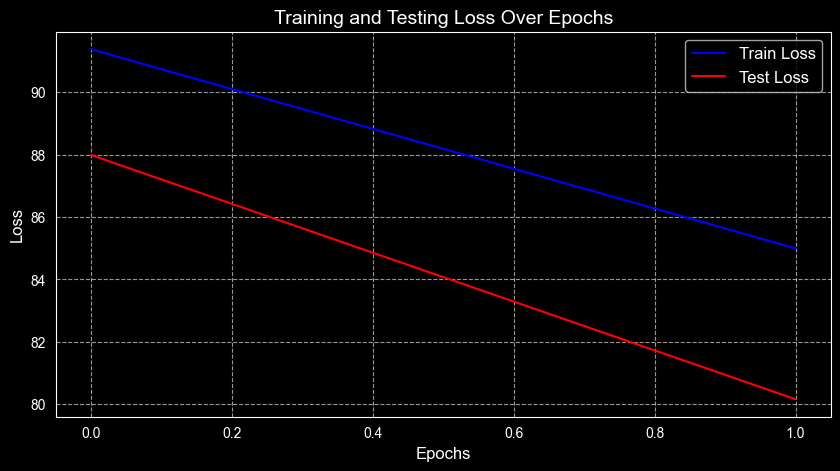

✅ متد Train بدون خطا تا انتها اجرا شد و نمودار خطا رسم گردید!


In [824]:
# ۱. تعریف ابعاد و ساختار فرضی لایه‌ها برای تست سریع
input_dim = 576
output_dim = 10
layer_sizes = [128, 10]
conv_list = [("conv", 1, 5, 1)]  # لایه کانولوشن با ۱ فیلتر و سایز ۵

# ۲. ساخت یک نمونه (Instance) از کلاس شبکه عصبی شما
print("در حال ساخت مدل...")
model = neural_networks(
    input_dim=input_dim,
    output_dim=output_dim,
    layer_sizes=layer_sizes,
    conv_list=conv_list,
    mod_opt="momentum",
    activation="sigmoid"
    # مقداردهی اولیه به صورت خودکار در همین مرحله انجام می‌شود
)

# 🔴 گام ۳ (فراخوانی مجدد initialize_weights) کاملاً حذف شد تا وزن‌ها دوبرابر نشوند!

# ۴. تولید داده‌های ساختگی کوچک برای تست یک چرخه کامل (فقط ۲ نمونه تصویر)
X_dummy = np.random.randn(2, 1, 28, 28)
y_dummy = np.random.randn(2, 10) # برچسب‌های فرضی لایه آخر

print("\n=== شروع تست گام به گام ===")

# تست اکشن رفت (Forward)
try:
    pred = model.forward(X_dummy)
    print("after forward:", model.filter_list[0].shape)
    print(f"✅ تست Forward با موفقیت انجام شد! ابعاد خروجی مدل: {pred.shape}")
except Exception as e:
    print(f"❌ خطا در بخش Forward: {e}")

# تست اکشن برگشت (Backward)
try:
    model.backward(X_dummy, y_dummy)
    print("after backward:", model.filter_list[0].shape)
    print("✅ تست Backward با موفقیت انجام شد! گرادیان‌ها محاسبه شدند.")
except Exception as e:
    print(f"❌ خطا در بخش Backward: {e}")

# تست به‌روزرسانی وزن‌ها (Update)
try:
    model.update(t=1, lr=0.001)
    print("✅ تست Update با موفقیت انجام شد! وزن‌ها به‌روزرسانی شدند.")
except Exception as e:
    print(f"❌ خطا در بخش Update: {e}")


print("\n=== شروع تست متد جامع Train ===")
# ساخت داده‌های آموزشی و تست ساختگی بیشتر برای سنجش تابع train
X_train_dummy = np.random.randn(10, 1, 28, 28)
y_train_dummy = np.random.randn(10, 10)
X_test_dummy = np.random.randn(4, 1, 28, 28)
y_test_dummy = np.random.randn(4, 10)

try:
    model.train(
        training_data=(X_train_dummy, y_train_dummy),
        testing_data=(X_test_dummy, y_test_dummy),
        epochs=2,
        batch_size=2,
        lr=0.001
    )
    print("✅ متد Train بدون خطا تا انتها اجرا شد و نمودار خطا رسم گردید!")
except Exception as e:
    print(f"❌ خطا در اجرای متد Train: {e}")